# **TCC - PERFIS DE DESEMPENHO NO ENEM(2018–2023) EM MUNICÍPIOS DA ÁREA DE ABRANGÊNCIA DO IFNMG**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [16]:
import os
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

### **Realizando a leitura da base de área de MG**

In [17]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Codificação das variáveis**
Nesse caso, será realizado a transformação da variável **TP_SEXO**, convertendo o valor 'M' para 0 e o valor 'F' para 1.

In [18]:
df_final["TP_SEXO"] = df_final["TP_SEXO"].map({"F": 1, "M": 0})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, a variável **TP_ESTADO_CIVIL** foi recodificada para valores numéricos, de forma que Solteiro(a) foi representado por 0, Casado(a)/Companheiro(a) por 1, e as demais categorias (Divorciado(a), Desquitado(a), Separado(a) e Viúvo(a)) foram agrupadas sob o valor 2, representando o grupo “Outros”

In [19]:
df_final["TP_ESTADO_CIVIL"] = df_final["TP_ESTADO_CIVIL"].replace({
    "Solteiro(a)": 0,
    "Casado(a)/Companheiro(a)": 1,
    "Divorciado(a)/Separado(a)": 2,
    "Desquitado(a)": 2,
    "Viúvo(a)": 2
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, aplicou-se o método one-hot encoding à variável **TP_COR_RACA**, criando colunas binárias (0 e 1) para cada categoria de cor/raça. Essa transformação permite representar variáveis categóricas de forma numérica, sem atribuir uma ordem entre as categorias.

In [20]:
df_final = pd.get_dummies(df_final, columns=["TP_COR_RACA"], prefix="COR_RACA")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,1,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,1,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,1,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,1,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,1,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,3,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,1,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,1,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,1,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_NACIONALIDADE**, transformando as categorias originais em valores numéricos binários:

0 → Brasileiro(a), Brasileiro(a) Naturalizado(a) ou Brasileiro(a) Nato(a), nascido(a) no exterior

1 → Estrangeiro(a)

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [21]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_NACIONALIDADE"] != 0].copy()

df_final.loc[:, "TP_NACIONALIDADE"] = df_final["TP_NACIONALIDADE"].replace({
    1: 0,  # Brasileiro(a)
    2: 0,  # Brasileiro(a) Naturalizado(a)
    4: 0,  # Brasileiro(a) Nato(a), nascido(a) no exterior
    3: 1   # Estrangeiro(a)
})

depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517827
Total de linhas após a exclusão: 517522
Foram removidas 305 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_NACIONALIDADE**, o conjunto de dados passou de 517827 para 517522 registros, resultando na exclusão de 305 observações com nacionalidade “Não informada”.

Nesta etapa, será realizada a recodificação da variável **TP_ENSINO**, transformando as categorias originais em valores numéricos binários:

0 → Educação Especial – Modalidade Substitutiva e Educação de Jovens e Adultos

1 → Ensino Regular

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [22]:
df_final.loc[:, "TP_ENSINO"] = df_final["TP_ENSINO"].replace({
    2: 0,  # Educação Especial – Modalidade Substitutiva
    3: 0  # Educação de Jovens e Adultos
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_ESCOLA**, transformando as categorias originais em valores numéricos binários:

0 → Pública

1 → Exterior e Privada

As observações com valor 1 (Não respondeu) serão removidas do conjunto de dados.

In [23]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_ESCOLA"] != 1].copy()

df_final.loc[:, "TP_ESCOLA"] = df_final["TP_ESCOLA"].replace({
    2: 0,  # Pública
    3: 1,  # Exterior
    4: 1   # Privada
})
depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517522
Total de linhas após a exclusão: 511774
Foram removidas 5748 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_ESCOLA**, o conjunto de dados passou de 517522 para 511774 registros, resultando na exclusão de 5748 observações com nacionalidade “Não respondeu”.

Nesta etapa, será realizada a recodificação da variável **ESQ_PAI, ESC_MAE, OCU_PAI, OCU_MAE, RENDA_MENSAL, EMP_DOMESTICO, BANHEIRO, QTD_QUARTOS, CARRO, MOTO, GELADEIRA, FREEZER, LAVA_ROUPA, SECA_ROUPA, MICROONDAS, LAVA_LOUCA, ASPIRADOR, TV, DVD, TV_ASSINATURA, CELULAR, TELEFONE_FIXO, COMPUTADOR, INTERNET**, transformando as categorias originais em valores numéricos binários

In [24]:
colunas_categoricas = [
    'ESQ_PAI', 'ESC_MAE', 'OCU_PAI', 'OCU_MAE', 'RENDA_MENSAL',
    'EMP_DOMESTICO', 'BANHEIRO', 'QTD_QUARTOS', 'CARRO', 'MOTO',
    'GELADEIRA', 'FREEZER', 'LAVA_ROUPA', 'SECA_ROUPA', 'MICROONDAS',
    'LAVA_LOUCA', 'ASPIRADOR', 'TV', 'DVD', 'TV_ASSINATURA',
    'CELULAR', 'TELEFONE_FIXO', 'COMPUTADOR', 'INTERNET'
]
mapa = {chr(i + 65): i for i in range(26)}  # 'A'->0, 'B'->1, ..., 'Z'->25

for col in colunas_categoricas:
    df_final[col] = df_final[col].map(mapa)

df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,1.0,1.0,1.0,1.0,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,1.0,0.0,0.0,0.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,2.0,0.0,0.0,1.0,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,4.0,0.0,3.0,1.0,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,3.0,0.0,1.0,1.0,False,False,False,True,False,False


### **Filtrando a área de abrangencia do IFNMG**

In [25]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
6,2018,2,0,0.0,0,2,0,1.0,Chapada do Norte,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
9,2018,3,1,0.0,0,2,0,1.0,Teófilo Otoni,MG,...,4.0,0.0,1.0,1.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,0.0,2.0,1.0,False,False,False,True,False,False
517781,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,1.0,0.0,0.0,1.0,False,False,False,True,False,False
517789,2023,4,0,1.0,0,2,0,NaN,Teófilo Otoni,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517799,2023,2,0,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,1.0,2.0,1.0,False,False,False,True,False,False


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [27]:
df_scaler = df_ifnmg
excluir = ["NO_MUNICIPIO_ESC", "SG_UF_ESC"]

colunas_para_escalar = [c for c in df_scaler.columns if c not in excluir]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])
df_scaler

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_7908\4233387697.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,-1.108611,0.060143,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Rio Pardo de Minas,MG,...,0.500841,-0.295584,-0.803232,-1.731054,8.143051,-0.543132,-0.40194,-1.196244,-0.15566,-0.077428
1,-1.108611,-0.584541,0.815464,-1.466988,-0.02419,0.0,-0.321396,0.161927,São Francisco,MG,...,0.500841,-0.295584,-0.803232,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
4,-1.108611,-0.584541,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Montalvânia,MG,...,-0.429485,-0.295584,0.572921,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
6,-1.108611,-0.584541,-1.226295,-1.466988,-0.02419,0.0,-0.321396,0.161927,Chapada do Norte,MG,...,-0.429485,-0.295584,0.572921,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
9,-1.108611,0.060143,0.815464,-1.466988,-0.02419,0.0,-0.321396,0.161927,Teófilo Otoni,MG,...,1.431168,-0.295584,0.572921,0.577683,-0.122804,1.841172,-0.40194,-1.196244,-0.15566,-0.077428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,1.768912,0.060143,0.815464,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,1.431168,-0.295584,1.949074,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
517781,1.768912,0.060143,0.815464,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,-1.359812,-0.295584,-0.803232,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428
517789,1.768912,0.704826,-1.226295,0.549446,-0.02419,0.0,-0.321396,NaN,Teófilo Otoni,MG,...,0.500841,-0.295584,-0.803232,0.577683,-0.122804,1.841172,-0.40194,-1.196244,-0.15566,-0.077428
517799,1.768912,-0.584541,-1.226295,0.549446,-0.02419,0.0,-0.321396,0.161927,Montes Claros,MG,...,1.431168,3.383129,1.949074,0.577683,-0.122804,-0.543132,-0.40194,0.835950,-0.15566,-0.077428


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

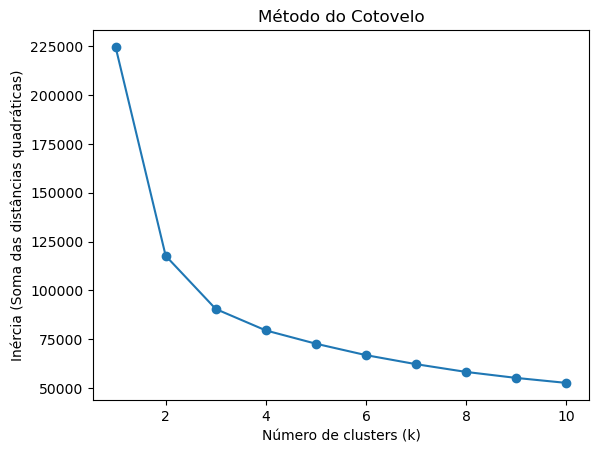

In [28]:
df_notas = df_ifnmg
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

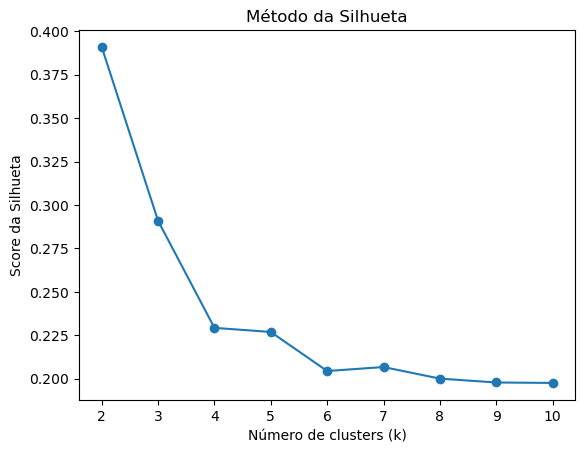

In [29]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Algumas variáveis [sexo, faixa etaria, tipo de escola e escolaridade e renda]**

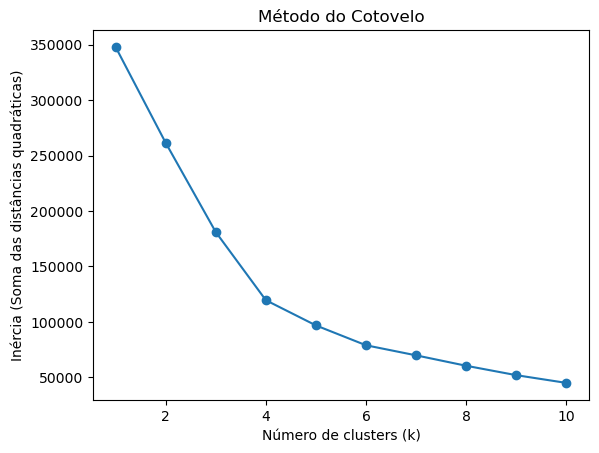

In [ ]:
df = df_ifnmg

# Selecionar apenas as variáveis desejadas
variaveis = df[["TP_SEXO", "TP_FAIXA_ETARIA", "TP_ESCOLA", "TP_ENSINO", "RENDA_MENSAL"]]

# Remover linhas com NaN nas colunas
variaveis = variaveis.dropna()

# Transformar variáveis categóricas em dummies (one-hot encoding)
variaveis_encoded = pd.get_dummies(variaveis, drop_first=True)

# Normalizar (opcional, mas ajuda o KMeans)
scaler = StandardScaler()
variaveis_normalizadas = scaler.fit_transform(variaveis_encoded)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(variaveis_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

# Calcular silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(variaveis_normalizadas)
    score = silhouette_score(variaveis_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()